In [2]:
from src import *
# ----------------------------------------------------------------------------------
# Plotting parameters
# ----------------------------------------------------------------------------------
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    'text.latex.preamble':r'\usepackage{amsmath}',
    'text.latex.preamble':r'\usepackage{fourier}'
})
w, l, l_log = 1.25, 10, 6
pad, lpad, shrink = 0.12, 5, 0.8

In [3]:
# ----------------------------------------------------------------------------------
# Getting the input data
# ----------------------------------------------------------------------------------
conf = inifix.load("idefix.ini")
n_vtk=52
n_average=515
r_min = conf["Grid"]["X1-grid"][1]
r_max = conf["Grid"]["X1-grid"][-1]
n_r = conf["Grid"]["X1-grid"][2]
epsilon = conf["Setup"]["epsilon"]
alpha = conf["Setup"]["alpha"]
densityFloor = conf["Setup"]["densityFloor"]
gravity = conf["Setup"]["gravity"]
beta_0 = conf["Setup"]["tilt"] * np.pi/180
spin = conf["Setup"]["spin"]

# Reading the analysis files
t, M_tot = READ_BOX_AVERAGE()
r, Sigma, rho_mean, L, beta, gamma, LBH, betaBH, gammaBH, rho_Vr, rho_Vperp = READ_RADIAL_AVERAGE(n_average, n_r, beta_0)


In [4]:
# ----------------------------------------------------------------------------------
# Normalizations and useful quantities
# ----------------------------------------------------------------------------------
# Time
r_norm = 5         # cf. NP2000
grad_Phi = 0
if gravity == "Kepler":
    grad_Phi = 1/r_norm**2
elif gravity == "Einstein":
    grad_Phi = 1/r_norm**2 + 6/r_norm**3
omega_orbit = 1/r_norm * np.sqrt(r_norm * grad_Phi)         # The 2pi is missing and it's normal
n_orbit = (t[-1]*omega_orbit)
t *= omega_orbit
T, R = np.meshgrid(t, r, indexing="ij")
# Radial averages
LBH_unit = np.zeros_like(LBH)
LBH_unit[:,:,0] = LBH[:,:,0] / np.sqrt(LBH[:,:,0]**2 + LBH[:,:,1]**2 + LBH[:,:,2]**2)
LBH_unit[:,:,1] = LBH[:,:,1] / np.sqrt(LBH[:,:,0]**2 + LBH[:,:,1]**2 + LBH[:,:,2]**2)
LBH_unit[:,:,2] = LBH[:,:,2] / np.sqrt(LBH[:,:,0]**2 + LBH[:,:,1]**2 + LBH[:,:,2]**2)
psi = R * np.sqrt(np.gradient(LBH_unit[:,:,0], r, axis=1)**2 + np.gradient(LBH_unit[:,:,1], r, axis=1)**2 + np.gradient(LBH_unit[:,:,2], r, axis=1)**2)
# zeta = np.gradient(betaBH, t, axis=0)    # Nodal precession frequency
# eta = np.gradient(gammaBH, t, axis=0)     # Apsidal precession frequency
# Must implement for every gravitationnal potential ! --------------------------------------------------------------------------------------------------------------
# if spin != 0:
#     if gravity == "Kepler":
#         omega2_E = 1/R**3 - 2*spin/R**(9/2)
#         zeta_th = 1/omega2_E * (-4*spin) / (2*R**(3/2) - 4*spin)
#         eta_th = 1/omega2_E * 3*spin / (2*R**(3/2) - 4*spin)
#     elif gravity == "Einstein":
#         omega2_E = 1/R**3 * (1 + 6/R) - 2*spin/R**(9/2)
#         zeta_th = -2*spin / (omega2_E * R**(9/2))
#         eta_th = -1/(2*omega2_E) * (6/R**4 - 3*spin/R**(9/2))
#     t_visc = 1 / (alpha * np.sqrt(omega2_E)) * epsilon**(-2)       # To verify (especially that omega)
#     M_dot_visc = Sigma[0,0]*(2*np.pi*R[0,0]**2*epsilon) / t_visc
#     M_dot = 2*np.pi*R * Sigma * (-rho_Vr / rho_mean)
#     M_dot /= M_dot_visc
#     zeta /= zeta_th
#     eta /= eta_th
# else:
#     omega_K = KEPLER(r)
#     t_visc = 1 / (alpha * np.sqrt(omega_K)) * epsilon**(-2)       # To verify (especially that omega)
#     M_dot_visc = Sigma[0,0]*(2*np.pi*R[0,0]**2*epsilon) / t_visc
#     M_dot = 2*np.pi*R * Sigma * (-rho_Vr / rho_mean)
#     M_dot /= M_dot_visc

M_dot = np.mean(2*np.pi*R * Sigma * (-rho_Vr / rho_mean), axis=0)
omega_K = KEPLER(r)
c_s = np.sqrt(1/r)
M_dot_visc = 2*np.pi*r * Sigma[0,:] * (alpha*epsilon*c_s)
omega_perp = np.mean(rho_Vperp / (R * rho_mean), axis=0)
kappa2_perp = 4*omega_perp**2 + 2*r*omega_perp*np.gradient(omega_perp, r)

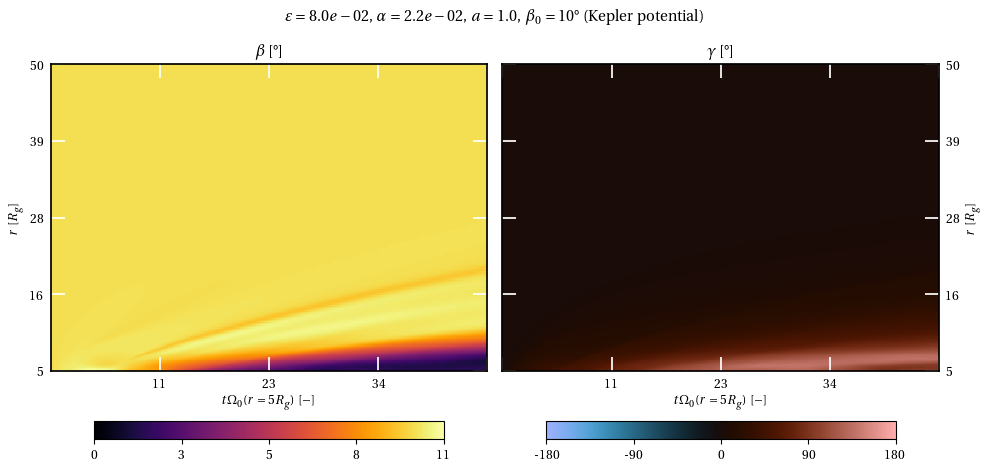

In [5]:
# ----------------------------------------------------------------------------------
# angles color plot
# ----------------------------------------------------------------------------------
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

ax = axs[0]
ax.set_title(r"$\beta$ $[$°$]$")
buff = np.max(np.abs(betaBH))
ticks = np.linspace(0, buff, 5)
pc0 = ax.pcolormesh(T, R, betaBH, cmap="inferno", vmin=0, vmax=buff)
formats = tkr.FormatStrFormatter('%.0f')
cbar = fig.colorbar(pc0, ax=ax, location="bottom", pad=pad, shrink=shrink, format=formats, ticks=ticks)
ax.tick_params(axis='both', direction='in', color='white', width=w, length=l, pad=lpad)
ax.set_facecolor("black")
ax.set_xlabel(rf"$t\Omega_0(r={r_norm}R_g)$ $[-]$")
ax.set_ylabel(r"$r$ $[R_g]$", labelpad=lpad)
ax.set_xlim((0, n_orbit))
xplot = np.linspace(0, n_orbit, 5)
xl = [f"{i:.0f}" for i in xplot]
xl[0] = ""
xl[-1] = ""
ax.set_xticks(xplot,xl)
ax.set_ylim((r_min, r_max))
yplot = np.linspace(r_min, r_max, 5)
yl = [f"{i:.0f}" for i in yplot]
ax.set_yticks(yplot, yl)
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
for spine in ax.spines.values():
    spine.set_linewidth(w)

ax = axs[1]
ax.set_title(r"$\gamma$ $[$°$]$")
buff = 180
ticks = np.linspace(-buff, buff, 5)
pc0 = ax.pcolormesh(T, R, gammaBH, cmap="berlin", vmin=-buff, vmax=buff)
formats = tkr.FormatStrFormatter('%.0f')
cbar = fig.colorbar(pc0, ax=ax, location="bottom", pad=pad, shrink=shrink, format=formats, ticks=ticks)
ax.tick_params(axis='both', direction='in', color='white', width=w, length=l, pad=lpad)
ax.set_facecolor("black")
ax.set_xlabel(rf"$t\Omega_0(r={r_norm}R_g)$ $[-]$")
ax.set_ylabel(r"$r$ $[R_g]$", labelpad=lpad)
ax.set_xlim((0, n_orbit))
ax.set_ylim((-180,180))
yplot = np.linspace(-180, 180, 5)
ax.set_yticks(yplot)
xplot = np.linspace(0, n_orbit, 5)
xl = [f"{i:.0f}" for i in xplot]
xl[0] = ""
xl[-1] = ""
ax.set_xticks(xplot,xl)
ax.set_ylim((r_min, r_max))
yplot = np.linspace(r_min, r_max, 5)
yl = [f"{i:.0f}" for i in yplot]
ax.set_yticks(yplot, yl)
ax.yaxis.set_label_position("right")
ax.yaxis.tick_right()
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
for spine in ax.spines.values():
    spine.set_linewidth(w)

fig.suptitle(rf"$\varepsilon = {epsilon:.1e}$, $\alpha = {alpha:.1e}$, $a = {spin:0.1f}$, $\beta_0 = {beta_0*180/np.pi:.0f}$° ({gravity} potential)")
fig.tight_layout()
plt.savefig(f"./plots/angles.png", bbox_inches='tight', dpi=500)
plt.show()
plt.close()

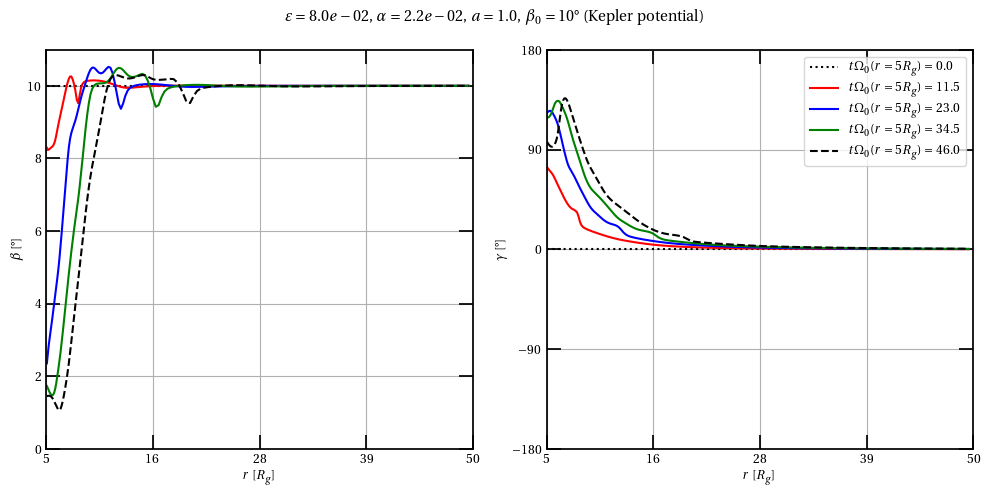

In [7]:
# ----------------------------------------------------------------------------------
# angles vs. radius plots
# ----------------------------------------------------------------------------------
n0 = 0
n1 = np.where(t >= n_orbit/4)[0][0]
n2 = np.where(t >= 2*n_orbit/4)[0][0]
n3 = np.where(t >= 3*n_orbit/4)[0][0]
n4 = -1

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

ax = axs[0]
ax.plot(r, betaBH[n0,:], color="black", linestyle="dotted")
ax.plot(r, betaBH[n1,:], color="red")
ax.plot(r, betaBH[n2,:], color="blue")
ax.plot(r, betaBH[n3,:], color="green")
ax.plot(r, betaBH[n4,:], color="black", linestyle="dashed")
ax.set_xlim((r_min, r_max))
xplot = np.linspace(r_min, r_max, 5)
xl = [f"{i:.0f}" for i in xplot]
ax.set_xticks(xplot, xl)
ax.set_ylim(bottom=0)
ax.set_xlabel(r"$r$ $[R_g]$")
ax.set_ylabel(r"$\beta$ $[$°$]$")
ax.tick_params(axis='y', which='both', direction='in', right=True, width=w, length=l)
ax.tick_params(axis='x', which='both', direction='in', top=True, width=w, length=l)
for spine in ax.spines.values():
        spine.set_linewidth(w)
ax.grid()

ax = axs[1]
ax.plot(r, gammaBH[n0,:], color="black", linestyle="dotted", label=rf"$t\Omega_0(r = {r_norm}R_g) =$ {t[n0]:.1f}")
ax.plot(r, gammaBH[n1,:], color="red", label=rf"$t\Omega_0(r = {r_norm}R_g) =$ {t[n1]:.1f}")
ax.plot(r, gammaBH[n2,:], color="blue", label=rf"$t\Omega_0(r = {r_norm}R_g) =$ {t[n2]:.1f}")
ax.plot(r, gammaBH[n3,:], color="green", label=rf"$t\Omega_0(r = {r_norm}R_g) =$ {t[n3]:.1f}")
ax.plot(r, gammaBH[n4,:], color="black", linestyle="dashed", label=rf"$t\Omega_0(r = {r_norm}R_g) =$ {t[n4]:.1f}")
ax.set_xlim((r_min, r_max))
ax.set_ylim((-180,180))
yplot = np.linspace(-180, 180, 5)
ax.set_yticks(yplot)
xplot = np.linspace(r_min, r_max, 5)
xl = [f"{i:.0f}" for i in xplot]
ax.set_xticks(xplot, xl)
ax.set_xlabel(r"$r$ $[R_g]$")
ax.set_ylabel(r"$\gamma$ $[$°$]$")
ax.tick_params(axis='y', which='both', direction='in', right=True, width=w, length=l)
ax.tick_params(axis='x', which='both', direction='in', top=True, width=w, length=l)
for spine in ax.spines.values():
        spine.set_linewidth(w)
ax.grid()
ax.legend()

fig.suptitle(rf"$\varepsilon = {epsilon:.1e}$, $\alpha = {alpha:.1e}$, $a = {spin:0.1f}$, $\beta_0 = {beta_0*180/np.pi:.0f}$° ({gravity} potential)")
fig.tight_layout()
plt.savefig(f"./plots/anglesVSradius.pdf", bbox_inches='tight')
plt.show()
plt.close()

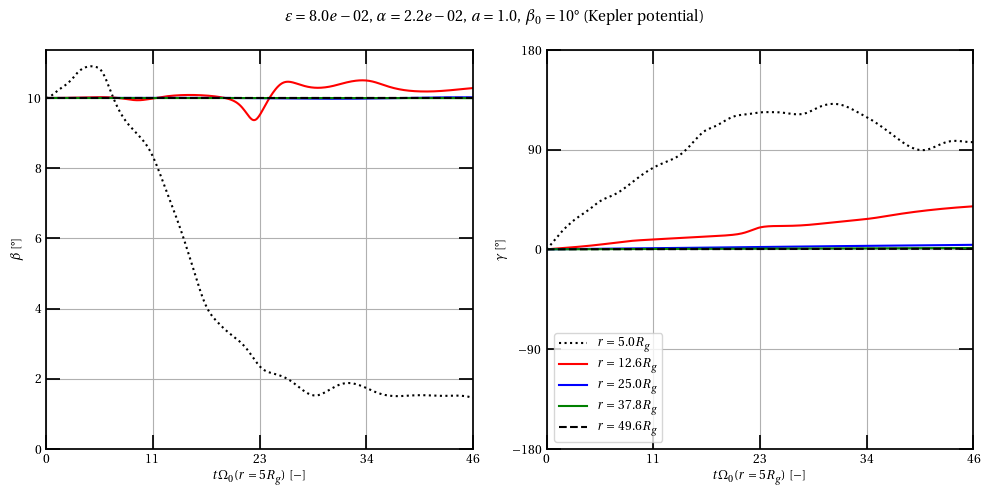

In [8]:
# ----------------------------------------------------------------------------------
# angles vs. time plots
# ----------------------------------------------------------------------------------
n0 = 0
n1 = np.where(r >= r_max/4)[0][0]
n2 = np.where(r >= 2*r_max/4)[0][0]
n3 = np.where(r >= 3*r_max/4)[0][0]
n4 = -1

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

ax = axs[0]
ax.plot(t, betaBH[:,n0], color="black", linestyle="dotted")
ax.plot(t, betaBH[:,n1], color="red")
ax.plot(t, betaBH[:,n2], color="blue")
ax.plot(t, betaBH[:,n3], color="green")
ax.plot(t, betaBH[:,n4], color="black", linestyle="dashed")
ax.set_xlim((0, n_orbit))
xplot = np.linspace(0, n_orbit, 5)
xl = [f"{i:.0f}" for i in xplot]
ax.set_xticks(xplot, xl)
ax.set_ylim(bottom=0)
ax.set_xlabel(rf"$t\Omega_0(r={r_norm}R_g)$ $[-]$")
ax.set_ylabel(r"$\beta$ $[$°$]$")
ax.tick_params(axis='y', which='both', direction='in', right=True, width=w, length=l)
ax.tick_params(axis='x', which='both', direction='in', top=True, width=w, length=l)
for spine in ax.spines.values():
        spine.set_linewidth(w)
ax.grid()

ax = axs[1]
ax.plot(t, gammaBH[:,n0], color="black", linestyle="dotted", label=rf"$r =$ {r[n0]:.1f}$R_g$")
ax.plot(t, gammaBH[:,n1], color="red", label=rf"$r =$ {r[n1]:.1f}$R_g$")
ax.plot(t, gammaBH[:,n2], color="blue", label=rf"$r =$ {r[n2]:.1f}$R_g$")
ax.plot(t, gammaBH[:,n3], color="green", label=rf"$r =$ {r[n3]:.1f}$R_g$")
ax.plot(t, gammaBH[:,n4], color="black", linestyle="dashed", label=rf"$r =$ {r[n4]:.1f}$R_g$")
ax.set_xlim((0, n_orbit))
ax.set_ylim((-180,180))
yplot = np.linspace(-180, 180, 5)
ax.set_yticks(yplot)
xplot = np.linspace(0, n_orbit, 5)
xl = [f"{i:.0f}" for i in xplot]
ax.set_xticks(xplot, xl)
ax.set_xlabel(rf"$t\Omega_0(r={r_norm}R_g)$ $[-]$")
ax.set_ylabel(r"$\gamma$ $[$°$]$")
ax.tick_params(axis='y', which='both', direction='in', right=True, width=w, length=l)
ax.tick_params(axis='x', which='both', direction='in', top=True, width=w, length=l)
for spine in ax.spines.values():
        spine.set_linewidth(w)
ax.grid()
ax.legend()

fig.suptitle(rf"$\varepsilon = {epsilon:.1e}$, $\alpha = {alpha:.1e}$, $a = {spin:0.1f}$, $\beta_0 = {beta_0*180/np.pi:.0f}$° ({gravity} potential)")
fig.tight_layout()
plt.savefig(f"./plots/anglesVStime.pdf", bbox_inches='tight')
plt.show()
plt.close()

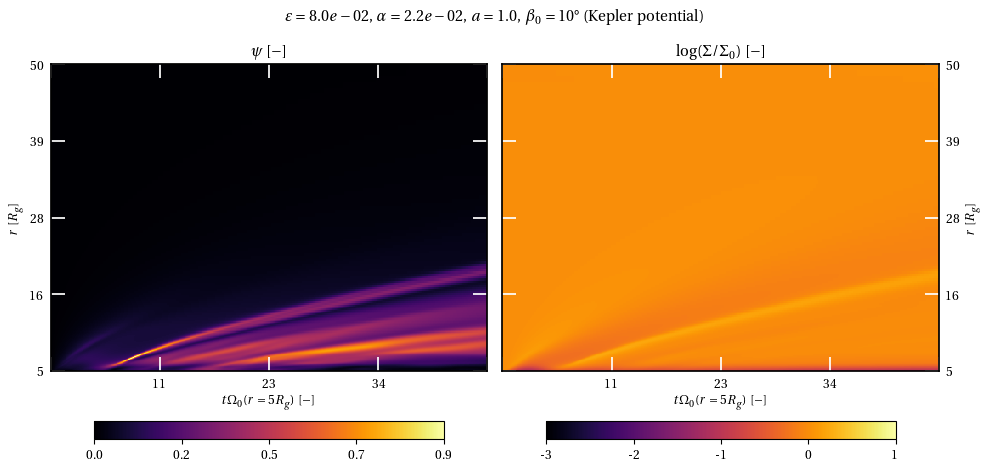

In [9]:
# ----------------------------------------------------------------------------------
# disk breaking color plot
# ----------------------------------------------------------------------------------
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

ax = axs[0]
ax.set_title(r"$\psi$ $[-]$")
buff = np.max(np.abs(psi))
ticks = np.linspace(0, buff, 5)
pc0 = ax.pcolormesh(T, R, psi, cmap="inferno", vmin=0, vmax=buff)
formats = tkr.FormatStrFormatter('%.1f')
cbar = fig.colorbar(pc0, ax=ax, location="bottom", pad=pad, shrink=shrink, format=formats, ticks=ticks)
ax.tick_params(axis='both', direction='in', color='white', width=w, length=l, pad=lpad)
ax.set_facecolor("black")
ax.set_xlabel(rf"$t\Omega_0(r={r_norm}R_g)$ $[-]$")
ax.set_ylabel(r"$r$ $[R_g]$", labelpad=lpad)
ax.set_xlim((0, n_orbit))
xplot = np.linspace(0, n_orbit, 5)
xl = [f"{i:.0f}" for i in xplot]
xl[0] = ""
xl[-1] = ""
ax.set_xticks(xplot,xl)
ax.set_ylim((r_min, r_max))
yplot = np.linspace(r_min, r_max, 5)
yl = [f"{i:.0f}" for i in yplot]
ax.set_yticks(yplot, yl)
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
for spine in ax.spines.values():
    spine.set_linewidth(w)

ax = axs[1]
ax.set_title(r"$\log(\Sigma/\Sigma_0)$ $[-]$")
ticks = np.linspace(-3, 1, 5)
Sigma_PLOT = np.zeros_like(Sigma)
for n in range(t.size):
    Sigma_PLOT[n,:] = Sigma[n,:] / Sigma[0,:]
pc0 = ax.pcolormesh(T, R, np.log10(Sigma_PLOT), cmap="inferno", vmin=-3, vmax=1)
formats = tkr.FormatStrFormatter('%.0f')
cbar = fig.colorbar(pc0, ax=ax, location="bottom", pad=pad, shrink=shrink, format=formats, ticks=ticks)
ax.tick_params(axis='both', direction='in', color='white', width=w, length=l, pad=lpad)
ax.set_facecolor("black")
ax.set_xlabel(rf"$t\Omega_0(r={r_norm}R_g)$ $[-]$")
ax.set_ylabel(r"$r$ $[R_g]$", labelpad=lpad)
ax.set_xlim((0, n_orbit))
xplot = np.linspace(0, n_orbit, 5)
xl = [f"{i:.0f}" for i in xplot]
xl[0] = ""
xl[-1] = ""
ax.set_xticks(xplot,xl)
ax.set_ylim((r_min, r_max))
yplot = np.linspace(r_min, r_max, 5)
yl = [f"{i:.0f}" for i in yplot]
ax.set_yticks(yplot, yl)
ax.yaxis.set_label_position("right")
ax.yaxis.tick_right()
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
for spine in ax.spines.values():
    spine.set_linewidth(w)

fig.suptitle(rf"$\varepsilon = {epsilon:.1e}$, $\alpha = {alpha:.1e}$, $a = {spin:0.1f}$, $\beta_0 = {beta_0*180/np.pi:.0f}$° ({gravity} potential)")
fig.tight_layout()
plt.savefig(f"./plots/disc_breaking.png", bbox_inches='tight', dpi=500)
plt.show()
plt.close()

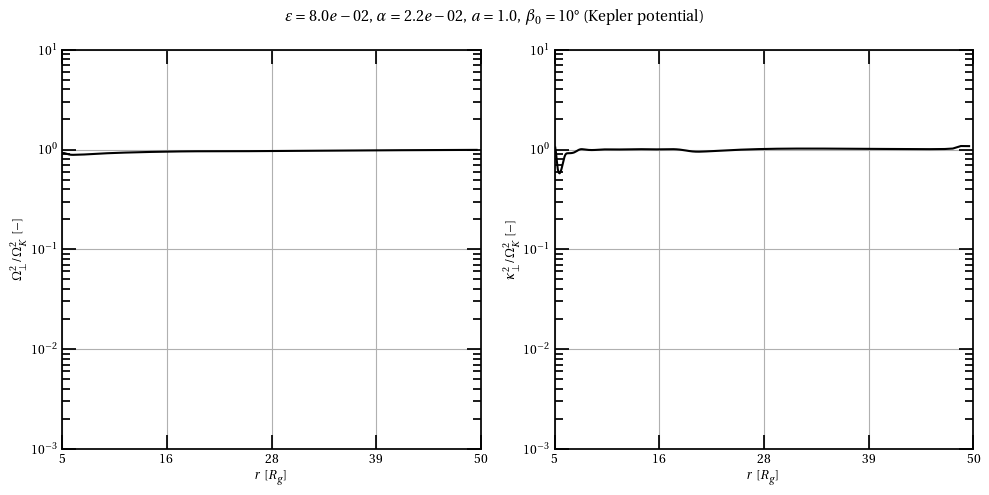

In [12]:
# ----------------------------------------------------------------------------------
# rotation curve plot
# ----------------------------------------------------------------------------------
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

ax = axs[0]
ax.plot(r, omega_perp**2/omega_K**2, color="black")
ax.set_xlim((r_min, r_max))
ax.set_xlabel(r"$r$ $[R_g]$")
xplot = np.linspace(r_min, r_max, 5)
xl = [f"{i:.0f}" for i in xplot]
ax.set_xticks(xplot, xl)
ax.set_yscale("log")
ax.set_ylim((1e-3, 1e1))
ax.set_ylabel(r"$\Omega_\perp^2/\Omega_K^2$ $[-]$")
ax.tick_params(axis='y', which='both', direction='in', right=True, width=w, length=l)
ax.tick_params(axis='x', which='both', direction='in', top=True, width=w, length=l)
ax.tick_params(axis='y', which='minor', length=l_log, width=w)
for spine in ax.spines.values():
        spine.set_linewidth(w)
ax.grid()

ax = axs[1]
ax.plot(r, kappa2_perp/omega_K**2, color="black")
ax.set_xlim((r_min, r_max))
ax.set_xlabel(r"$r$ $[R_g]$")
ax.set_xticks(xplot, xl)
ax.set_yscale("log")
ax.set_ylim((1e-3, 1e1))
ax.set_ylabel(r"$\kappa_\perp^2/\Omega_K^2$ $[-]$")
ax.tick_params(axis='y', which='both', direction='in', right=True, width=w, length=l)
ax.tick_params(axis='x', which='both', direction='in', top=True, width=w, length=l)
ax.tick_params(axis='y', which='minor', length=l_log, width=w)
for spine in ax.spines.values():
        spine.set_linewidth(w)
ax.grid()

fig.suptitle(rf"$\varepsilon = {epsilon:.1e}$, $\alpha = {alpha:.1e}$, $a = {spin:0.1f}$, $\beta_0 = {beta_0*180/np.pi:.0f}$° ({gravity} potential)")
fig.tight_layout()
plt.savefig(f"./plots/rotation_curve.pdf", bbox_inches='tight')
plt.show()
plt.close()

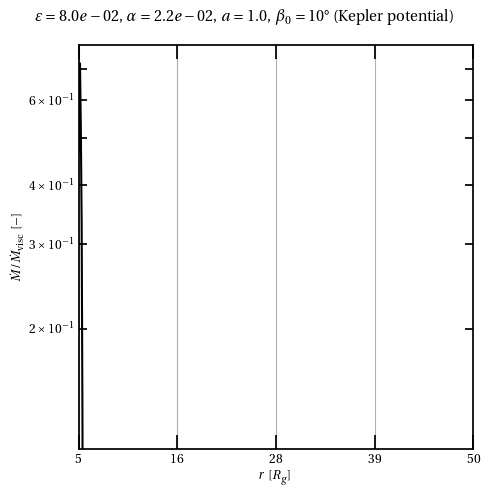

In [13]:
# ----------------------------------------------------------------------------------
# accretion rate
# ----------------------------------------------------------------------------------
fig, axs = plt.subplots(1, figsize=(5, 5))

ax = axs
ax.plot(r, M_dot/M_dot_visc, color="black")
ax.set_xlim((r_min, r_max))
ax.set_xlabel(r"$r$ $[R_g]$")
ax.set_xticks(xplot, xl)
ax.set_yscale("log")
# ax.set_ylim((1e-2, 1e1))
ax.set_ylabel(r"$\dot{M} / \dot{M}_\mathrm{visc}$ $[-]$")
ax.tick_params(axis='y', which='both', direction='in', right=True, width=w, length=l)
ax.tick_params(axis='x', which='both', direction='in', top=True, width=w, length=l)
ax.tick_params(axis='y', which='minor', length=l_log, width=w)
for spine in ax.spines.values():
        spine.set_linewidth(w)
ax.grid()

fig.suptitle(rf"$\varepsilon = {epsilon:.1e}$, $\alpha = {alpha:.1e}$, $a = {spin:0.1f}$, $\beta_0 = {beta_0*180/np.pi:.0f}$° ({gravity} potential)")
fig.tight_layout()
plt.savefig(f"./plots/accretion_rate.pdf", bbox_inches='tight')
plt.show()
plt.close()

In [ ]:
# ----------------------------------------------------------------------------------
# mass, velocity and source term movies
# ----------------------------------------------------------------------------------
mass_plots = []
mass_zoom_plots = []
velocity_xz_plots = []
velocity_zoom_xz_plots = []
velocity_yz_plots = []
velocity_zoom_yz_plots = []
sourceTerm_zoom_xz_plots = []
sourceTerm_zoom_yz_plots = []

for n in range(n_vtk):
    n_analysis = int(n * conf["Output"]["vtk"] // conf["Output"]["analysis"])
    r_vtk, theta_vtk, phi_vtk, rho, v_r, v_theta, v_phi = READ_VTK(n)
    PHI, TH, R = np.meshgrid(phi_vtk, theta_vtk, r_vtk, indexing="ij")

    c_s = epsilon / np.sqrt(R)
    mask = (rho > densityFloor * 2)

    # gravitomagnetic source term -----------------------------------------------------------------------------------------------------------------------
    Sx = np.sin(-beta_0) * spin
    Sy = 0
    Sz = np.cos(-beta_0) * spin
    Sr = np.sin(TH)*np.cos(PHI)*Sx + np.sin(TH)*np.sin(PHI)*Sy + np.cos(TH)*Sz
    Sth = np.cos(TH)*np.cos(PHI)*Sx + np.cos(TH)*np.sin(PHI)*Sy - np.sin(TH)*Sz
    Sphi = - np.sin(PHI)*Sx + np.cos(PHI)*Sy
    hr = -4*Sr / R**3
    hth = 2*Sth / R**3
    hphi = 2*Sphi / R**3

    Vcrossh_r = v_theta*hphi - v_phi*hth
    Vcrossh_th = v_phi*hr - v_r*hphi
    Vcrossh_phi = v_r*hth - v_theta*hr
    # ---------------------------------------------------------------------------------------------------------------------------------------------------

    # mass plots ------------------------------------------------------------------------------------------------------------------------
    quantities = {
        "densityFloor": densityFloor,
        "rho": rho,
        "beta_0": beta_0,
        "r_norm": r_norm
    }
    MASS_PLOT(r_vtk, r_min, r_max, theta_vtk, phi_vtk, quantities, False, mass_plots, f"mass_{n}", t[n_analysis])
    MASS_PLOT(r_vtk, r_min, r_max, theta_vtk, phi_vtk, quantities, True, mass_zoom_plots, f"mass_zoom_{n}", t[n_analysis])
    # ---------------------------------------------------------------------------------------------------------------------------------------------------

    # velocity plots ------------------------------------------------------------------------------------------------------------------------
    quantities = {
        "q_r": v_r*mask,
        "q_th": v_theta*mask,
        "q_phi": v_phi*mask,
        "buff_r": 0.1,
        "buff_th": 0.1,
        "buff_phi": 0.5,
        "title_r": r"$v_r$ $[$Code Units$]$",
        "title_th": r"$v_\theta$ $[$Code Units$]$",
        "title_phi": r"$v_\varphi$ $[$Code Units$]$",
        "beta_0": beta_0,
        "r_norm": r_norm
    }
    VELOCITY_PLOT(r_vtk, r_min, r_max, theta_vtk, phi_vtk, quantities, "xz", False, velocity_xz_plots, f"velocity_xz_{n}", t[n_analysis])
    VELOCITY_PLOT(r_vtk, r_min, r_max, theta_vtk, phi_vtk, quantities, "xz", True, velocity_zoom_xz_plots, f"velocity_zoom_xz_{n}", t[n_analysis])
    VELOCITY_PLOT(r_vtk, r_min, r_max, theta_vtk, phi_vtk, quantities, "yz", False, velocity_yz_plots, f"velocity_yz_{n}", t[n_analysis])
    VELOCITY_PLOT(r_vtk, r_min, r_max, theta_vtk, phi_vtk, quantities, "yz", True, velocity_zoom_yz_plots, f"velocity_zoom_yz_{n}", t[n_analysis])

    quantities = {
        "q_r": Vcrossh_r*mask,
        "q_th": Vcrossh_th*mask,
        "q_phi": Vcrossh_phi*mask,
        "buff_r": 0.005,
        "buff_th": 0.005,
        "buff_phi": 0.002,
        "title_r": r'$(v\times h)_r$ $[$Code Units$]$',
        "title_th": r'$(v\times h)_\theta$ $[$Code Units$]$',
        "title_phi": r'$(v\times h)_\varphi$ $[$Code Units$]$',
        "beta_0": beta_0,
        "r_norm": r_norm
    }
    VELOCITY_PLOT(r_vtk, r_min, r_max, theta_vtk, phi_vtk, quantities, "xz", True, sourceTerm_zoom_xz_plots, f"sourceTerm_zoom_xz_{n}", t[n_analysis])
    VELOCITY_PLOT(r_vtk, r_min, r_max, theta_vtk, phi_vtk, quantities, "yz", True, sourceTerm_zoom_yz_plots, f"sourceTerm_zoom_yz_{n}", t[n_analysis])

In [ ]:
MOVIE(mass_plots, "mass")
MOVIE(mass_zoom_plots, "mass_zoom")

MOVIE(velocity_xz_plots, "velocity_xz")
MOVIE(velocity_zoom_xz_plots, "velocity_zoom_xz")
MOVIE(velocity_yz_plots, "velocity_yz")
MOVIE(velocity_zoom_yz_plots, "velocity_zoom_yz")

MOVIE(sourceTerm_zoom_xz_plots, "sourceTerm_zoom_xz")
MOVIE(sourceTerm_zoom_yz_plots, "sourceTerm_zoom_yz")